In [1]:
%matplotlib notebook

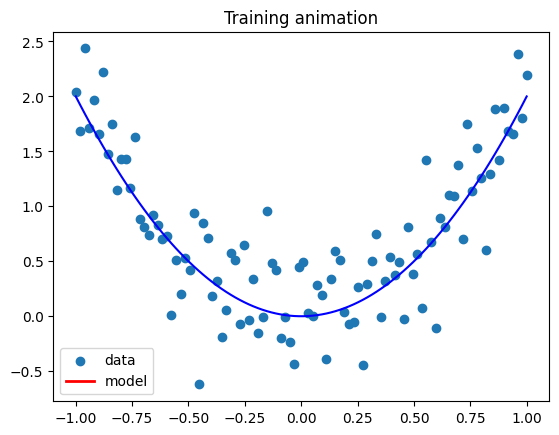

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

# ------------------------------
# Данные
# ------------------------------
x = torch.linspace(-1, 1, 100).reshape(-1, 1)
yy = 2 * x ** 2
N = 0.3 * torch.randn_like(x)
y = yy + N

# ------------------------------
# Модель
# ------------------------------
model = nn.Sequential(
    nn.Linear(1, 16),
    nn.ReLU(),
    nn.Linear(16, 1)
)

optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

# ------------------------------
# Подготовка графика
# ------------------------------
fig, ax = plt.subplots()
scatter = ax.scatter(x.detach(), y.detach(), label="data")
line, = ax.plot([], [], color='red', linewidth=2, label="model")
ax.legend()
ax.set_title("Training animation")
ax.plot(x,yy, color="blue")


# ------------------------------
# Функция обновления
# ------------------------------
def update(frame):
    for _ in range(5):  # несколько шагов на кадр
        y_pred = model(x)
        loss = criterion(y_pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # обновляем линию
    with torch.no_grad():
        y_pred = model(x)
        line.set_data(x.numpy(), y_pred.numpy())

    ax.set_title(f"Epoch {frame}, Loss {loss.item():.4f}")
    return line,


# ------------------------------
# Анимация
# ------------------------------
ani = FuncAnimation(fig, update, frames=100, interval=200)

plt.show()

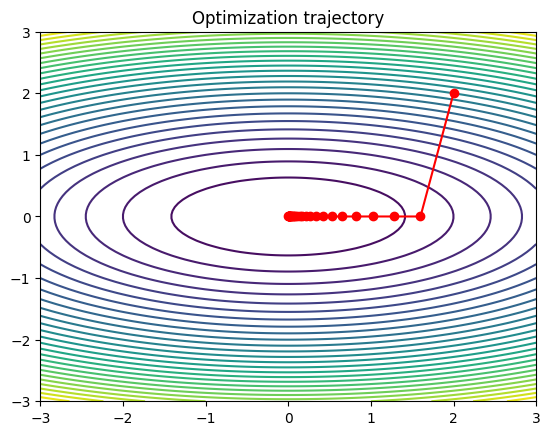

In [26]:
def loss_2d(w):
    return w[0]**2 + 5*w[1]**2

def grad_2d(w):
    return np.array([2*w[0], 10*w[1]])

w = np.array([2.0, 2.0])
lr = 0.1

trajectory = []

for _ in range(30):
    trajectory.append(w.copy())
    w = w - lr * grad_2d(w)

trajectory = np.array(trajectory)

# contour plot
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = X**2 + 5*Y**2


%matplotlib inline
plt.contour(X, Y, Z, levels=30)
plt.plot(trajectory[:,0], trajectory[:,1], 'ro-')
plt.title("Optimization trajectory")
plt.show()